In [53]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import networkx as nx
import random

df = pd.read_csv("MetObjects.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

/var/folders/wj/xzbvl19s7qdg2sxs_dz30hb80000gn/T/ipykernel_35487/2037856656.py:9: DtypeWarning: Columns (5,7,10,11,12,13,14,34,35,36,37,38,39,40,41,42,43,44,45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("MetObjects.csv")


Shape: (484956, 54)

Columns:
['Object Number', 'Is Highlight', 'Is Timeline Work', 'Is Public Domain', 'Object ID', 'Gallery Number', 'Department', 'AccessionYear', 'Object Name', 'Title', 'Culture', 'Period', 'Dynasty', 'Reign', 'Portfolio', 'Constituent ID', 'Artist Role', 'Artist Prefix', 'Artist Display Name', 'Artist Display Bio', 'Artist Suffix', 'Artist Alpha Sort', 'Artist Nationality', 'Artist Begin Date', 'Artist End Date', 'Artist Gender', 'Artist ULAN URL', 'Artist Wikidata URL', 'Object Date', 'Object Begin Date', 'Object End Date', 'Medium', 'Dimensions', 'Credit Line', 'Geography Type', 'City', 'State', 'County', 'Country', 'Region', 'Subregion', 'Locale', 'Locus', 'Excavation', 'River', 'Classification', 'Rights and Reproduction', 'Link Resource', 'Object Wikidata URL', 'Metadata Date', 'Repository', 'Tags', 'Tags AAT URL', 'Tags Wikidata URL']

First few rows:


,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979.0,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980.0,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN


In [54]:
japan_mask = df['Culture'].str.contains('Japan', na=False)
print(df[japan_mask]['Department'].value_counts())

Department
Asian Art                                 17148
Arms and Armor                             5276
Costume Institute                           461
Musical Instruments                         219
European Sculpture and Decorative Arts      121
The American Wing                            19
Robert Lehman Collection                      4
Name: count, dtype: int64


In [55]:
print("=== Culture ===")
print(f"Unique values: {df['Culture'].nunique()}")
print(df['Culture'].value_counts().head(30))

print("\n=== Period ===")
print(f"Unique values: {df['Period'].nunique()}")
print(df['Period'].value_counts().head(30))

=== Culture ===
Unique values: 7313
Culture
American                28579
French                  18435
Greek, Attic            17309
Japan                   16939
China                   13504
Italian                  6526
Japanese                 5990
British                  5476
Roman                    4872
German                   4576
Cypriot                  2904
European                 2669
American or European     2052
Coptic                   1674
French, Paris            1622
Spanish                  1563
British, London          1408
Greek                    1263
Etruscan                 1234
Iran                     1070
Dutch                     920
Sasanian                  916
Chinese                   905
Mexican                   843
German, Meissen           829
Frankish                  753
Italian, Venice           730
Russian                   719
Indonesia (Java)          697
Indian                    678
Name: count, dtype: int64

=== Period ===
Unique values:

In [56]:
french = df[df['Culture'].str.contains('French', na=False)]
print(f"Total French objects: {len(french)}")
print(f"\nPeriods in French culture objects:")
print(french['Period'].value_counts().head(30))

Total French objects: 25260

Periods in French culture objects:
Series([], Name: count, dtype: int64)


In [57]:
print(f"Object Date examples:")
print(french['Object Date'].value_counts().head(20))

print(f"\nBegin Date range: {french['Object Begin Date'].min()} – {french['Object Begin Date'].max()}")
print(f"End Date range: {french['Object End Date'].min()} – {french['Object End Date'].max()}")

Object Date examples:
Object Date
18th century               2014
19th century               1983
early 19th century          602
17th–18th century           387
late 18th century           298
17th century                245
early 18th century          187
18th–19th century           176
15th century                174
late 19th century           159
1750–60                     156
mid-18th century            152
16th century                135
14th century                134
late 12th century           131
ca. 1785                    131
first half 19th century     128
1815–30                     127
ca. 1750                    125
mid-19th century            125
Name: count, dtype: int64

Begin Date range: 0 – 2020
End Date range: 0 – 2020


In [58]:
ca1785 = french[french['Object Date'] == 'ca. 1785']
print(ca1785['Classification'].value_counts().head(15))
print()
print(ca1785['Department'].value_counts())

Classification
Textiles-Printed                    39
Textiles-Embroidered                36
Woodwork-Furniture                  22
Metalwork-Gilt Bronze               13
Fans                                 4
Swords                               1
Woodwork                             1
Ceramics-Porcelain                   1
Horology                             1
Sculpture                            1
Metalwork-Bronze                     1
Snuffboxes                           1
Chordophone-Lute-plucked-fretted     1
Woodwork-Architectural               1
Name: count, dtype: int64

Department
European Sculpture and Decorative Arts    120
Costume Institute                           8
Arms and Armor                              1
Robert Lehman Collection                    1
Musical Instruments                         1
Name: count, dtype: int64


In [59]:
enlightenment = french[
    (french['Object Begin Date'] >= 1680) & 
    (french['Object End Date'] <= 1800)
]
print(f"French objects 1680–1800: {len(enlightenment)}")
print(f"\nClassifications:")
print(enlightenment['Classification'].value_counts().head(20))
print(f"\nDepartments:")
print(enlightenment['Department'].value_counts())

French objects 1680–1800: 7060

Classifications:
Classification
Textiles-Woven                            1093
Ceramics-Porcelain                         756
Metalwork-Gilt Bronze                      712
Woodwork-Furniture                         452
Metalwork-Silver                           433
Textiles-Laces                             390
Woodwork                                   294
Ceramics-Pottery                           247
Textiles-Printed                           224
Metalwork-Gold and Platinum                207
Textiles-Trimmings                         188
Textiles-Embroidered                       152
Fans                                       149
Textiles-Tapestries                        140
Sculpture                                  112
Horology                                    95
Metalwork-Gold and Platinum|Miniatures      92
Swords                                      83
Textiles-Velvets                            78
Glass                                      

In [60]:
print(f"\nObject Names:")
print(enlightenment['Object Name'].value_counts().head(30))


Object Names:
Object Name
Piece                 1210
Plate                  303
Fan                    174
Fragment               151
Panel                  138
Armchair               127
Snuffbox               114
Galloon                 95
Upholstery panel        69
Frame                   68
Tapestry                64
Button                  62
Ornament                61
Figure                  59
Dish                    55
Medallion               54
Vase                    53
Clock ornament          49
Box                     48
Snuffbox, painting      47
Bust                    41
Medal                   40
Furnishing textile      40
Smallsword              39
Souvenir                38
Sample                  37
Candlesticks            37
Étui                    35
Statuette               35
Border                  35
Name: count, dtype: int64


In [61]:
french_swords = enlightenment[
    enlightenment['Classification'].str.contains('Sword', na=False)
]
print(f"French swords 1680–1800: {len(french_swords)}")
print(f"\nObject Names:")
print(french_swords['Object Name'].value_counts())
print(f"\nObject Dates:")
print(french_swords['Object Date'].value_counts().head(15))
print(f"\nMedium:")
print(french_swords['Medium'].value_counts().head(15))

French swords 1680–1800: 92

Object Names:
Object Name
Smallsword                                         39
Smallsword with scabbard                           16
Page's sword                                        6
Sword belt                                          4
Hunting sword                                       4
Hunting sword with scabbard                         3
Sword carrier                                       2
Hunting sword (Couteau de Chasse)                   1
Linstoc sword                                       1
Smallsword blade                                    1
Colichemarde blade                                  1
Presentation sword                                  1
Officer's smallsword with scabbard                  1
Smallsword with sheath                              1
Combination hunting sword and pistol                1
Military sword                                      1
Hunting sword (Couteau de Chasse) with scabbard     1
Short sword with scabbard  

In [62]:
japanese_swords = df[
    (df['Culture'].str.contains('Japan', na=False)) &
    (df['Classification'].str.contains('Sword', na=False))
]
print(f"Japanese swords: {len(japanese_swords)}")
print(f"\nObject Names:")
print(japanese_swords['Object Name'].value_counts().head(20))
print(f"\nPeriods:")
print(japanese_swords['Period'].value_counts().head(15))
print(f"\nMedium:")
print(japanese_swords['Medium'].value_counts().head(15))

Japanese swords: 3398

Object Names:
Object Name
Sword guard (Tsuba)                                                                 1210
Knife handle (Kozuka)                                                               1087
Sword-hilt collar and pommel (Fuchigashira)                                          506
Pair of sword-grip ornaments (Menuki)                                                131
Blade and mounting for a short sword (Wakizashi)                                      46
Blade and mounting for a sword (Katana)                                               28
Sword-hilt collar (Fuchi)                                                             26
Blade for a sword (Katana)                                                            25
Sword guard (<i>Tsuba</i>)                                                            23
Sword pommel (Kashira)                                                                21
Set of sword fittings (Mitokoromono)                         

In [63]:
print(japanese_swords['Object Date'].value_counts().head(20))

Object Date
ca. 1615–1868                   1596
19th century                     509
18th century                     377
17th century                      94
late 18th–early 19th century      67
early 19th century                38
late 16th–early 17th century      31
16th century                      30
late 18th century                 25
mid-19th century                  24
late 17th century                 16
early 17th century                15
ca. 1800                          14
18th–19th century                 13
late 15th–early 16th century      13
ca. 3rd century–538               13
1828–98                           10
late 17th–early 18th century      10
early–mid-17th century            10
possibly 17th century              9
Name: count, dtype: int64


In [64]:
gold_silver_swords = df[
    (df['Classification'].str.contains('Sword', na=False)) &
    (df['Medium'].str.contains('gold|silver|Gold|Silver', na=False, regex=True))
]

print(f"Swords with gold or silver: {len(gold_silver_swords)}")

print(f"\n=== Culture (top 30) ===")
print(gold_silver_swords['Culture'].value_counts().head(30))

print(f"\n=== Period (top 30) ===")
print(gold_silver_swords['Period'].value_counts().head(30))

print(f"\n=== Object Date (top 30) ===")
print(gold_silver_swords['Object Date'].value_counts().head(30))

Swords with gold or silver: 3484

=== Culture (top 30) ===
Culture
Japanese                         2842
French                             80
Indian                             48
Italian                            45
Turkish                            21
German                             19
French, Paris                      18
Persian                            16
British                            13
Chinese                            13
British, London                    12
Tibetan                            11
Caucasian                          10
hilt, Indian; blade, European      10
Burmese                            10
Spanish                             8
possibly French                     8
German, Saxony                      7
Malayan                             7
Sri Lankan                          6
German, Saxon                       5
Italian, Venice                     5
North Italian                       4
Turkish with Persian blade          4
hilt, Indian; blade, 

In [65]:
non_jp_gold_swords = gold_silver_swords[
    ~gold_silver_swords['Culture'].str.contains('Japan', na=False)
]

print(f"Non-Japanese gold/silver swords: {len(non_jp_gold_swords)}")

print(f"\n=== Culture ===")
print(non_jp_gold_swords['Culture'].value_counts().head(20))

print(f"\n=== Object Date ===")
print(non_jp_gold_swords['Object Date'].value_counts().head(20))

print(f"\n=== Object Names ===")
print(non_jp_gold_swords['Object Name'].value_counts().head(20))

print(f"\n=== Medium (top 15) ===")
print(non_jp_gold_swords['Medium'].value_counts().head(15))

Non-Japanese gold/silver swords: 632

=== Culture ===
Culture
French                           80
Indian                           48
Italian                          45
Turkish                          21
German                           19
French, Paris                    18
Persian                          16
British                          13
Chinese                          13
British, London                  12
Tibetan                          11
Caucasian                        10
Burmese                          10
hilt, Indian; blade, European    10
possibly French                   8
Spanish                           8
Malayan                           7
German, Saxony                    7
Sri Lankan                        6
German, Saxon                     5
Name: count, dtype: int64

=== Object Date ===
Object Date
18th–19th century        69
19th century             56
18th century             42
16th century             25
17th century             20
1750               

In [66]:
british_swords = gold_silver_swords[
    gold_silver_swords['Culture'].str.contains('British', na=False)
]
print(f"Total: {len(british_swords)}")
print(f"\nObject Names:")
print(british_swords['Object Name'].value_counts())
print(f"\nObject Date:")
print(british_swords['Object Date'].value_counts())
print(f"\nCredit Line (how they got to the Met):")
print(british_swords['Credit Line'].value_counts().head(10))

Total: 40

Object Names:
Object Name
Smallsword                               15
Basket-hilted sword                       4
Presentation smallsword with scabbard     3
Sword                                     3
Smallsword with scabbard                  3
Scabbard tip                              3
Sword with scabbard                       2
Smallsword hilt and scabbard mounts       1
Saber with scabbard                       1
Officer's sword with scabbard             1
Hunting sword                             1
Rapier                                    1
Cross hilt sword                          1
Smallsword with scabbard and case         1
Name: count, dtype: int64

Object Date:
Object Date
hallmarked for 1797–98                          3
16th century                                    3
ca. 1780–85                                     2
1600–1625                                       2
ca. 1780–1810                                   2
blade dated 1662                             

In [67]:
cultures = {
    'Japanese': 'Japan',
    'French': 'French',
    'British': 'British',
    'Italian': 'Italian',
}

for label, pattern in cultures.items():
    total = len(df[df['Culture'].str.contains(pattern, na=False)])
    swords = len(df[
        (df['Culture'].str.contains(pattern, na=False)) &
        (df['Classification'].str.contains('Sword', na=False))
    ])
    gold_swords = len(gold_silver_swords[
        gold_silver_swords['Culture'].str.contains(pattern, na=False)
    ])
    pct_swords = (swords / total * 100) if total > 0 else 0
    pct_gold = (gold_swords / swords * 100) if swords > 0 else 0
    
    print(f"{label:12s}  Total: {total:>7,}  "
          f"Swords: {swords:>5,} ({pct_swords:.1f}%)  "
          f"Gold/Silver swords: {gold_swords:>5,} ({pct_gold:.1f}% of swords)")

Japanese      Total:  23,248  Swords: 3,398 (14.6%)  Gold/Silver swords: 2,852 (83.9% of swords)
French        Total:  25,260  Swords:   167 (0.7%)  Gold/Silver swords:   127 (76.0% of swords)
British       Total:  11,957  Swords:    52 (0.4%)  Gold/Silver swords:    40 (76.9% of swords)
Italian       Total:  12,715  Swords:   188 (1.5%)  Gold/Silver swords:    76 (40.4% of swords)


In [68]:
for label, pattern in [('French', 'French'), ('British', 'British')]:
    subset = gold_silver_swords[
        gold_silver_swords['Culture'].str.contains(pattern, na=False)
    ]
    print(f"\n=== {label} gold/silver swords ({len(subset)}) ===")
    print(subset['Object Date'].value_counts().head(20))
    


=== French gold/silver swords (127) ===
Object Date
18th century              7
1785                      5
1750                      4
1775                      4
1780                      4
1790                      3
19th century              3
ca. 1780                  3
ca. 1760                  2
1753–54                   2
17th century              2
15th century              2
ca. 1790                  2
ca. 1750                  2
hallmarked for 1785–86    2
ca. 1650–60               2
1797–1809                 2
1770                      1
1775–1800                 1
1760                      1
Name: count, dtype: int64

=== British gold/silver swords (40) ===
Object Date
hallmarked for 1797–98                          3
16th century                                    3
ca. 1780–85                                     2
1600–1625                                       2
ca. 1780–1810                                   2
blade dated 1662                                1
ca. 1700

In [69]:
import numpy as np

for label, pattern in [('French', 'French'), ('British', 'British')]:
    subset = gold_silver_swords[
        gold_silver_swords['Culture'].str.contains(pattern, na=False)
    ].copy()
    subset['century'] = (subset['Object Begin Date'] // 100) * 100
    
    print(f"\n=== {label} gold/silver swords by century ===")
    print(subset['century'].value_counts().sort_index())


=== French gold/silver swords by century ===
century
1200     1
1300     1
1400     3
1500     9
1600    10
1700    92
1800    10
1900     1
Name: count, dtype: int64

=== British gold/silver swords by century ===
century
1500     4
1600    14
1700    16
1800     6
Name: count, dtype: int64


In [70]:
for item_type in ['Armor', 'Firearm', 'Pistol']:
    subset = df[df['Classification'].str.contains(item_type, na=False)]
    print(f"\n{'='*60}")
    print(f"{item_type}: {len(subset)} objects")
    print(f"{'='*60}")
    print(f"\nTop cultures:")
    print(subset['Culture'].value_counts().head(15))


Armor: 1360 objects

Top cultures:
Culture
Japanese                   320
Italian                    266
German                     201
German, Augsburg            52
Indian                      39
German, Nuremberg           34
French                      28
Italian, Milan              24
Turkish                     20
Spanish                     17
Chinese                     17
German, Landshut            16
Italian, probably Milan     14
British, Greenwich          12
Western European            11
Name: count, dtype: int64

Firearm: 1090 objects

Top cultures:
Culture
Japanese           99
German             96
French             57
Italian            52
Turkish            50
Persian            39
Indian             34
American           29
British, London    25
French, Paris      23
Moroccan           23
German, Saxony     21
Chinese            20
Tibetan            17
Spanish            17
Name: count, dtype: int64

Pistol: 285 objects

Top cultures:
Culture
German             

In [71]:
cultures = {
    'Japanese': 'Japan',
    'French': 'French',
    'British': 'British',
    'Italian': 'Italian',
    'German': 'German',
}

for item_type in ['Armor', 'Firearm', 'Pistol']:
    print(f"\n{'='*70}")
    print(f"{item_type} — gold/silver by culture")
    print(f"{'='*70}")
    for label, pattern in cultures.items():
        total = len(df[
            (df['Culture'].str.contains(pattern, na=False)) &
            (df['Classification'].str.contains(item_type, na=False))
        ])
        precious = len(df[
            (df['Culture'].str.contains(pattern, na=False)) &
            (df['Classification'].str.contains(item_type, na=False)) &
            (df['Medium'].str.contains('gold|silver|Gold|Silver', na=False, regex=True))
        ])
        pct = (precious / total * 100) if total > 0 else 0
        print(f"  {label:12s}  Total: {total:>5,}  "
              f"Gold/Silver: {precious:>5,} ({pct:.1f}%)")


Armor — gold/silver by culture
  Japanese      Total:   322  Gold/Silver:    46 (14.3%)
  French        Total:    49  Gold/Silver:    28 (57.1%)
  British       Total:    27  Gold/Silver:    18 (66.7%)
  Italian       Total:   347  Gold/Silver:    62 (17.9%)
  German        Total:   375  Gold/Silver:    95 (25.3%)

Firearm — gold/silver by culture
  Japanese      Total:   100  Gold/Silver:    32 (32.0%)
  French        Total:   102  Gold/Silver:    58 (56.9%)
  British       Total:    43  Gold/Silver:    29 (67.4%)
  Italian       Total:    90  Gold/Silver:    25 (27.8%)
  German        Total:   191  Gold/Silver:    74 (38.7%)

Pistol — gold/silver by culture
  Japanese      Total:    11  Gold/Silver:     4 (36.4%)
  French        Total:    33  Gold/Silver:    25 (75.8%)
  British       Total:    25  Gold/Silver:    20 (80.0%)
  Italian       Total:    34  Gold/Silver:    14 (41.2%)
  German        Total:    57  Gold/Silver:    25 (43.9%)


In [72]:
for label, pattern in [('French', 'French'), ('British', 'British')]:
    subset = df[
        (df['Culture'].str.contains(pattern, na=False)) &
        (df['Classification'].str.contains('Pistol', na=False)) &
        (df['Medium'].str.contains('gold|silver|Gold|Silver', na=False, regex=True))
    ]
    
    print(f"\n=== {label} gold/silver pistols ({len(subset)}) ===")
    print(f"\nBy century:")
    century = (subset['Object Begin Date'] // 100) * 100
    print(century.value_counts().sort_index())
    print(f"\nObject Dates:")
    print(subset['Object Date'].value_counts().head(15))
    print(f"\nObject Names:")
    print(subset['Object Name'].value_counts().head(10))


=== French gold/silver pistols (25) ===

By century:
Object Begin Date
1500     4
1600     2
1700     8
1800    11
Name: count, dtype: int64

Object Dates:
Object Date
18th century           2
dated 1851             2
ca. 1640               1
dated 1849             1
ca. 1570–80            1
dated 1849 and 1851    1
1860–80                1
dated 1694             1
ca. 1800               1
late 18th century      1
ca. 1850               1
dated 1856             1
dated 1829             1
ca. 1600–1610          1
1752–53                1
Name: count, dtype: int64

Object Names:
Object Name
Pair of wheellock pistols                            2
Cased pair of percussion pistols with accessories    2
Flintlock pistol                                     2
Percussion target pistol                             2
Wheellock pistol                                     2
Pair of flintlock pistols                            2
Cased pair of percussion pistols                     1
Two percussion tar

In [73]:
from scipy.stats import chi2_contingency
import numpy as np

cultures = {
    'Japanese': 'Japan',
    'French': 'French',
    'British': 'British',
    'Italian': 'Italian',
    'German': 'German',
}

rows = []
for label, pattern in cultures.items():
    total = len(df[
        (df['Culture'].str.contains(pattern, na=False)) &
        (df['Classification'].str.contains('Pistol', na=False))
    ])
    precious = len(df[
        (df['Culture'].str.contains(pattern, na=False)) &
        (df['Classification'].str.contains('Pistol', na=False)) &
        (df['Medium'].str.contains('gold|silver|Gold|Silver', na=False, regex=True))
    ])
    rows.append([precious, total - precious])

contingency = np.array(rows)
chi2, p, dof, expected = chi2_contingency(contingency)

print("Contingency table (gold/silver vs plain):")
labels = list(cultures.keys())
for i, label in enumerate(labels):
    print(f"  {label:12s}  precious: {rows[i][0]:>3}  plain: {rows[i][1]:>3}")

print(f"\nχ² = {chi2:.3f}")
print(f"df = {dof}")
print(f"p  = {p:.6f}")

print(f"\nExpected frequencies:")
for i, label in enumerate(labels):
    print(f"  {label:12s}  precious: {expected[i][0]:.1f}  plain: {expected[i][1]:.1f}")

Contingency table (gold/silver vs plain):
  Japanese      precious:   4  plain:   7
  French        precious:  25  plain:   8
  British       precious:  20  plain:   5
  Italian       precious:  14  plain:  20
  German        precious:  25  plain:  32

χ² = 19.085
df = 4
p  = 0.000756

Expected frequencies:
  Japanese      precious: 6.0  plain: 5.0
  French        precious: 18.1  plain: 14.8
  British       precious: 13.8  plain: 11.2
  Italian       precious: 18.7  plain: 15.3
  German        precious: 31.4  plain: 25.6


In [74]:
# Without Japan — just the four European cultures
rows_euro = rows[1:]  # French, British, Italian, German
contingency_euro = np.array(rows_euro)
chi2_e, p_e, dof_e, expected_e = chi2_contingency(contingency_euro)

print("European cultures only:")
labels_euro = list(cultures.keys())[1:]
for i, label in enumerate(labels_euro):
    print(f"  {label:12s}  precious: {rows_euro[i][0]:>3}  plain: {rows_euro[i][1]:>3}")
print(f"\nχ² = {chi2_e:.3f}, df = {dof_e}, p = {p_e:.6f}")

European cultures only:
  French        precious:  25  plain:   8
  British       precious:  20  plain:   5
  Italian       precious:  14  plain:  20
  German        precious:  25  plain:  32

χ² = 17.538, df = 3, p = 0.000548


In [75]:
for label, pattern in [('French', 'French'), ('British', 'British')]:
    subset = df[
        (df['Culture'].str.contains(pattern, na=False)) &
        (df['Classification'].str.contains('Pistol', na=False))
    ].copy()
    subset['half_century'] = (subset['Object Begin Date'] // 50) * 50
    
    precious = df[
        (df['Culture'].str.contains(pattern, na=False)) &
        (df['Classification'].str.contains('Pistol', na=False)) &
        (df['Medium'].str.contains('gold|silver|Gold|Silver', na=False, regex=True))
    ].copy()
    precious['half_century'] = (precious['Object Begin Date'] // 50) * 50
    
    print(f"\n=== {label} pistols by half-century ===")
    all_counts = subset['half_century'].value_counts().sort_index()
    prec_counts = precious['half_century'].value_counts().sort_index()
    
    for period in all_counts.index:
        total = all_counts[period]
        gold = prec_counts.get(period, 0)
        plain = total - gold
        pct = (gold / total * 100) if total > 0 else 0
        print(f"  {int(period)}–{int(period)+49}:  "
              f"total {total:>3}  precious {gold:>3}  plain {plain:>3}  "
              f"({pct:.0f}%)")


=== French pistols by half-century ===
  1500–1549:  total   1  precious   1  plain   0  (100%)
  1550–1599:  total   3  precious   3  plain   0  (100%)
  1600–1649:  total   3  precious   1  plain   2  (33%)
  1650–1699:  total   1  precious   1  plain   0  (100%)
  1700–1749:  total   3  precious   3  plain   0  (100%)
  1750–1799:  total   8  precious   5  plain   3  (62%)
  1800–1849:  total   9  precious   7  plain   2  (78%)
  1850–1899:  total   5  precious   4  plain   1  (80%)

=== British pistols by half-century ===
  1650–1699:  total   1  precious   0  plain   1  (0%)
  1700–1749:  total   2  precious   2  plain   0  (100%)
  1750–1799:  total  14  precious  12  plain   2  (86%)
  1800–1849:  total   8  precious   6  plain   2  (75%)


In [76]:
for label, pattern in [('French', 'French'), ('British', 'British')]:
    print(f"\n=== {label} — precious metal % by weapon type and century ===")
    for weapon in ['Sword', 'Armor', 'Firearm', 'Pistol']:
        subset = df[
            (df['Culture'].str.contains(pattern, na=False)) &
            (df['Classification'].str.contains(weapon, na=False))
        ].copy()
        subset['century'] = (subset['Object Begin Date'] // 100) * 100
        
        precious = df[
            (df['Culture'].str.contains(pattern, na=False)) &
            (df['Classification'].str.contains(weapon, na=False)) &
            (df['Medium'].str.contains('gold|silver|Gold|Silver', na=False, regex=True))
        ].copy()
        precious['century'] = (precious['Object Begin Date'] // 100) * 100
        
        all_c = subset['century'].value_counts().sort_index()
        prec_c = precious['century'].value_counts().sort_index()
        
        print(f"\n  {weapon}:")
        for century in all_c.index:
            t = all_c[century]
            g = prec_c.get(century, 0)
            pct = (g / t * 100) if t > 0 else 0
            if t >= 3:  # only show centuries with at least 3 objects
                print(f"    {int(century)}s: {t:>4} total  {g:>4} precious  ({pct:.0f}%)")


=== French — precious metal % by weapon type and century ===

  Sword:
    1100s:    3 total     0 precious  (0%)
    1200s:    3 total     1 precious  (33%)
    1400s:    5 total     3 precious  (60%)
    1500s:   15 total     9 precious  (60%)
    1600s:   21 total    10 precious  (48%)
    1700s:  107 total    92 precious  (86%)
    1800s:   11 total    10 precious  (91%)

  Armor:
    1400s:    3 total     0 precious  (0%)
    1500s:   30 total    18 precious  (60%)
    1600s:    5 total     4 precious  (80%)
    1700s:    4 total     3 precious  (75%)
    1800s:    6 total     2 precious  (33%)

  Firearm:
    1300s:    3 total     0 precious  (0%)
    1500s:   23 total    15 precious  (65%)
    1600s:   19 total     6 precious  (32%)
    1700s:   32 total    19 precious  (59%)
    1800s:   24 total    18 precious  (75%)

  Pistol:
    1500s:    4 total     4 precious  (100%)
    1600s:    4 total     2 precious  (50%)
    1700s:   11 total     8 precious  (73%)
    1800s:   14 t

In [77]:
japanese = df[df['Culture'].str.contains('Japan', na=False)]

print(japanese['Object Name'].value_counts().head(30))
print(japanese['Classification'].value_counts().head(30))

Object Name
Piece                                          3300
Print                                          3173
Sword guard (Tsuba)                            1210
Knife handle (Kozuka)                          1087
Netsuke                                         939
Hanging scroll                                  830
Woodblock print                                 731
Illustrated book                                577
Stencil                                         570
Inrō                                            539
Sword-hilt collar and pommel (Fuchigashira)     506
Arrowhead (<i>Yanone</i>)                       482
Dish                                            274
Woodblock print (nishiki-e)                     265
Bowl                                            234
Vase                                            199
Sample                                          195
Teabowl                                         183
Tea jar                                         178


In [78]:
print_classifications = ['Prints', 'Illustrated Books', 'Stencils']
japanese_prints = japanese[japanese['Classification'].isin(print_classifications)]
print(japanese_prints['Department'].value_counts())

Department
Asian Art                   5503
Robert Lehman Collection       2
Name: count, dtype: int64


In [79]:
japanese_in_dp = df[(df['Culture'].str.contains('Japan', na=False)) & 
                    (df['Department']=='Drawings and Prints')]
print(japanese_in_dp['Classification'].value_counts().head(20))
print(japanese_in_dp['Object Name'].value_counts().head(20))

Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)


In [80]:
dp = df[df['Department']=='Drawings and Prints']
print(dp['Culture'].isna().sum())
print(len(dp))

172630
172630


In [81]:
dp = df[df['Department']=='Drawings and Prints']
coverage = (dp.notna() & (dp != '')).sum() / len(dp) * 100
print(coverage.sort_values(ascending=False).round(1))

Object Number              100.0
Object End Date            100.0
Is Timeline Work           100.0
Is Public Domain           100.0
Object ID                  100.0
Repository                 100.0
Department                 100.0
Link Resource              100.0
Classification             100.0
Is Highlight               100.0
Object Begin Date          100.0
Title                      100.0
Credit Line                 99.9
Object Name                 99.8
AccessionYear               99.3
Object Date                 98.6
Medium                      97.6
Artist Role                 96.7
Artist Prefix               96.7
Artist Display Name         96.7
Artist Display Bio          96.7
Artist Alpha Sort           96.7
Artist Nationality          96.7
Artist Begin Date           96.7
Artist End Date             96.7
Constituent ID              96.7
Artist Suffix               96.6
Dimensions                  96.1
Artist ULAN URL             76.8
Artist Wikidata URL         76.2
Tags Wikid

In [82]:
print(dp['Artist Nationality'].value_counts().head(60))

Artist Nationality
American                                                   32775
French                                                     12225
                                                           11501
Italian                                                     9670
French|French                                               8311
American|American                                           7719
British                                                     7303
German                                                      5221
Italian|Italian                                             4821
French|French|French                                        4678
British|British                                             3797
American|                                                   3055
Dutch                                                       2407
British|British|British                                     2229
Italian|Italian|Italian                                     1413
Nether

In [83]:
diaspora = df[df['Artist Nationality'].str.contains('born', case=False, na=False)]
print(diaspora['Artist Nationality'].value_counts().head(30))

Artist Nationality
American, born Germany                      1023
American, born Hungary                       394
American, born England                       371
American, born Russia                        371
American, born France                        310
French, born Algeria|French                  306
French, born Russia                          261
American, born Poland                        239
American|American, born England              228
American, born Cuba                          217
American, born The Netherlands               203
American, born Ireland                       202
American, born Germany|American|American     169
American, born Greece                        164
American, born Germany|American              163
American, born Sweden                        160
French, born Prussia                         155
British, born India                          154
American, born Austria                       150
American|American, born Ireland              139
B

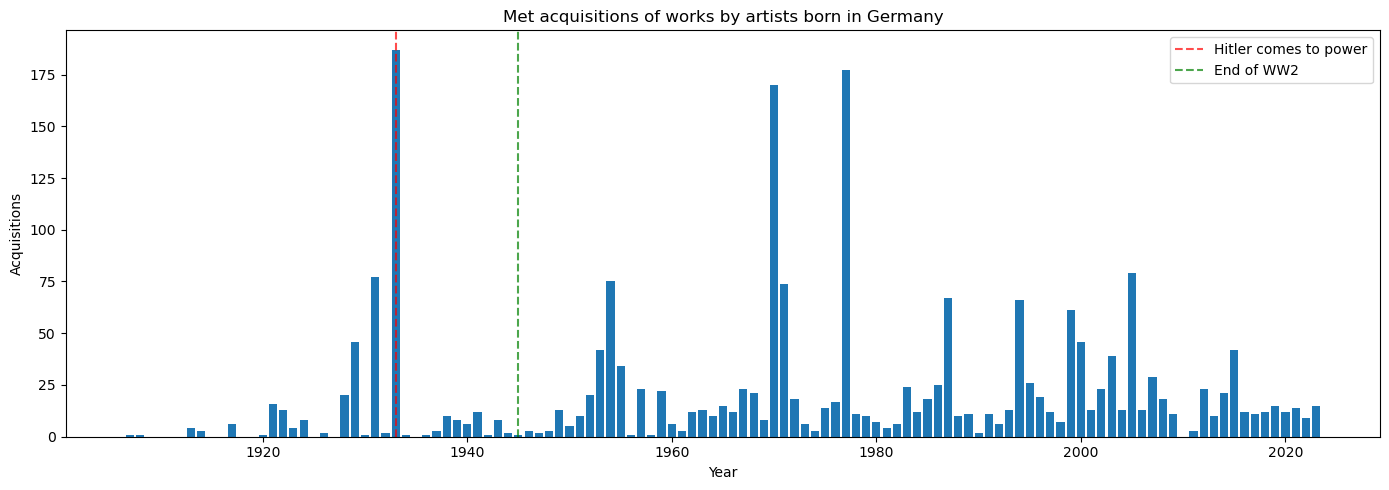

In [84]:
import matplotlib.pyplot as plt

yearly = born_germany['AccessionYear'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(yearly.index, yearly.values)
plt.axvline(x=1933, color='red', linestyle='--', alpha=0.7, label='Hitler comes to power')
plt.axvline(x=1945, color='green', linestyle='--', alpha=0.7, label='End of WW2')
plt.xlabel('Year')
plt.ylabel('Acquisitions')
plt.title('Met acquisitions of works by artists born in Germany')
plt.legend()
plt.tight_layout()
plt.show()

In [85]:
spike = born_germany[born_germany['AccessionYear']==1933]
print(spike['Artist Display Name'].value_counts().head(20))

Artist Display Name
Thomas Nast                                              129
Heinrich Kühn                                             14
Arnold Genthe                                              6
Thomas Nast|Joseph T. Speer                                4
Cyril Nast|Thomas Nast                                     3
Oscar Wilde|Thomas Nast                                    2
Thomas Nast|James G. Blaine                                2
Thomas Nast|Harper & Brothers                              2
Thomas Nast|Joseph Norton Dolph                            1
Samuel J. Tilden|Thomas Nast|Thomas A. Hendricks           1
George Washington|Thomas Nast                              1
Charles Henry Parkhurst|Thomas Nast                        1
Annie Oakley|Thomas Nast                                   1
Wilhelm Tell|Charles Henry Parkhurst|Thomas Nast           1
Time Publishing Co.|Thomas Nast                            1
Time Publishing Co.|Benjamin Harrison|Thomas Nast          1
Time

In [86]:
print(born_germany[['Artist Display Name', 'Artist Begin Date', 'Artist End Date', 'Object Begin Date', 'Object End Date', 'Department', 'Classification']].head(20))

                                     Artist Display Name  Artist Begin Date  \
997                                         Daniel Pabst             1826.0   
3457   Henry William Stiegel|American Flint Glass Man...                NaN   
4381                               Henry William Stiegel             1729.0   
6231   American Flint Glass Manufactory|Henry William...                NaN   
6232   Henry William Stiegel|American Flint Glass Man...                NaN   
7430                               Henry William Stiegel             1729.0   
7443   Henry William Stiegel|Stenger Glass House|Amer...                NaN   
8047   American Flint Glass Manufactory|Henry William...                NaN   
9141                               Henry William Stiegel             1729.0   
9142                               Henry William Stiegel             1729.0   
10506                       Joseph Christian Leyendecker             1874.0   
10507                       Joseph Christian Leyende

In [88]:
born_germany['Artist Begin Date'] = pd.to_numeric(born_germany['Artist Begin Date'], errors='coerce')
refugees = born_germany[(born_germany['Artist Begin Date'] >= 1880) & 
                        (born_germany['Artist Begin Date'] <= 1920)]
print(refugees['Artist Display Name'].value_counts().head(20))

Artist Display Name
Josef Albers                  152
Anni Albers                    79
Bill Brandt                    78
Josef Breitenbach              58
Wilhelm von Gloeden            48
Hans Hofmann                   41
John Gutmann                   39
Hugo Brehme                    26
George Grosz                   26
Hanns Skolle                   25
Paul Grotz                     19
Emil Ganso                     19
Werner Drewes                  15
T. Lux Feininger               14
Peter Lipman-Wulf              13
Karl Schrag                    11
Jean Arp                       10
Lotte Jacobi                    8
Max Ernst                       8
Ludwig Heinrich Jungnickel      7
Name: count, dtype: int64


In [89]:
print(refugees.groupby(['Artist Display Name', 'Department']).size().unstack(fill_value=0))

Department                  Drawings and Prints  Modern and Contemporary Art  \
Artist Display Name                                                            
Adolf Fassbender                              0                            0   
Anni Albers                                   0                           79   
Bill Brandt                                   0                            0   
Carl Hoeckner                                 3                            0   
Emil Ganso                                   16                            3   
Erica Karawina                                3                            0   
Ernst Fuhrmann                                0                            0   
Fred G. Korth                                 0                            0   
Friedel Dzubas                                0                            1   
Fritz Henle                                   0                            0   
Gego (Gertrud Goldschmidt)              

In [90]:
coverage = (df.notna() & (df != '')).sum(axis=1)
df['completeness'] = coverage

print(df['completeness'].describe())

count    484956.000000
mean         27.335795
std           5.884357
min          11.000000
25%          22.000000
50%          30.000000
75%          32.000000
max          45.000000
Name: completeness, dtype: float64


In [91]:
sparse = df[df['completeness'] <= 15]
print(f"Objects with 15 or fewer fields: {len(sparse)}")
print(sparse['Department'].value_counts())

Objects with 15 or fewer fields: 79
Department
Drawings and Prints                       27
The Libraries                             14
Greek and Roman Art                       12
Musical Instruments                        8
The American Wing                          4
Islamic Art                                4
Asian Art                                  3
Modern and Contemporary Art                3
Costume Institute                          1
European Sculpture and Decorative Arts     1
European Paintings                         1
Photographs                                1
Name: count, dtype: int64


In [92]:
sparse_greek = df[(df['completeness'] <= 15) & (df['Department'] == 'Greek and Roman Art')]
print(sparse_greek[['Title', 'Object Name', 'Medium', 'Object Begin Date', 'Object End Date', 'AccessionYear']].to_string())

                                                                      Title              Object Name   Medium  Object Begin Date  Object End Date AccessionYear
429503                                                                 Vase                     Vase      NaN                  0                0        1917.0
448727                                                    Head of Aphrodite        Head of Aphrodite  Plaster                  0                0        1927.0
460734                   Copy in oils of a wall painting: Girl with flowers  Copy of a wall painting      NaN                  0                0        1906.0
460735      Copy in oils of a Pompeian wall painting: Erotes driving a goat  Copy of a wall painting      NaN                  0                0        1906.0
460736  Copy in oils of a Pompeian wall painting: Psyches gathering flowers  Copy of a wall painting      NaN                  0                0        1906.0
460737                               Cop

In [93]:
print(df[df.index == 429503].T)

                                                                    429503
Object Number                                                   17.194.273
Is Highlight                                                         False
Is Timeline Work                                                     False
Is Public Domain                                                     False
Object ID                                                           735346
Gallery Number                                                         NaN
Department                                             Greek and Roman Art
AccessionYear                                                       1917.0
Object Name                                                           Vase
Title                                                                 Vase
Culture                                                                NaN
Period                                                                 NaN
Dynasty                  

In [94]:
morgan = df[df['Credit Line'].str.contains('Morgan', na=False)]
print(f"Morgan objects: {len(morgan)}")
print(morgan['completeness'].describe())

Morgan objects: 7353
count    7353.000000
mean       23.251734
std         5.077139
min        15.000000
25%        19.000000
50%        22.000000
75%        25.000000
max        41.000000
Name: completeness, dtype: float64


In [95]:
print(morgan.groupby('Department')['completeness'].mean().sort_values())

Department
Costume Institute                            20.451613
Greek and Roman Art                          20.463855
Arms and Armor                               20.921053
Medieval Art                                 22.037181
Islamic Art                                  22.039474
Asian Art                                    22.579710
Ancient Near Eastern Art                     23.000000
Arts of Africa, Oceania, and the Americas    23.550000
European Sculpture and Decorative Arts       23.664352
Egyptian Art                                 24.046512
The American Wing                            24.666667
Photographs                                  28.037736
The Libraries                                30.000000
Drawings and Prints                          32.397924
Musical Instruments                          33.000000
The Cloisters                                33.000000
European Paintings                           33.652582
Modern and Contemporary Art                  34.000000